# Maximum Entropy (MaxEnt) Periyar - Combined

In [2]:
! pip install mlxtend

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import sklearn.metrics as metrics

# libraries for Multicollinearity
from sklearn.linear_model import LinearRegression

#libraries for feature selection
from sklearn.feature_selection import RFE
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

# libraries for optimize hyperparameters
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  # MaxEnt Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

In [6]:
# Load and balance dataset
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Combined_Multi_ML.csv"
df = pd.read_csv(csv_path)
print("Columns in the dataset:", df.columns)




Columns in the dataset: Index(['wkt_geom', 'Aspect1', 'DistToRoad', 'DistToStre', 'Elevation1',
       'FlowDir1', 'LULC1', 'NDBI1', 'NDVI1', 'NDWI1', 'PlanarCurv',
       'Rainfall1', 'Rainfall2', 'Rainfall3', 'Rainfall4', 'Rainfall5',
       'Rainfall6', 'Rainfall7', 'Rainfall8', 'Rainfall9', 'Rainfall10',
       'Rainfall11', 'Slope1', 'SPI1', 'STI1', 'TPI1', 'TRI1', 'TWI1', 'WRI1',
       'Target_Var'],
      dtype='object')


In [8]:

num_rows, num_columns = df.shape
print(f"Total Rows: {num_rows}")
print(f"Total Columns: {num_columns}")

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

Total Rows: 6432
Total Columns: 30

First 5 Rows:
                                            wkt_geom   Aspect1  DistToRoad  \
0  PointZ (660808.91387751756701618 1125912.32571...  0.452086   30.002138   
1  PointZ (655919.37658706970978528 1137256.37391...       NaN   42.430210   
2  PointZ (661792.93298613862134516 1138300.14105...       NaN  180.013779   
3  PointZ (646884.05534000787883997 1138047.13062...       NaN   67.090622   
4  PointZ (653209.34352380444761366 1139662.58189...       NaN   84.861305   

   DistToStre  Elevation1  FlowDir1  LULC1     NDBI1     NDVI1     NDWI1  ...  \
0  212.132034    0.083799  0.450980     10  0.445073  0.667561  0.271971  ...   
1  276.586334    0.064516  0.988858     10       NaN       NaN       NaN  ...   
2  150.000000    0.084375  0.587744     50       NaN       NaN       NaN  ...   
3   84.852814    0.266667  0.806723     10       NaN       NaN       NaN  ...   
4  228.473190    0.034562  0.376045     50       NaN       NaN       NaN  ..

Best hyperparameters (GridSearchCV): {'C': 10}

Accuracy: 0.6373
Precision (weighted): 0.6788
Recall (weighted): 0.6373
F1 Score (weighted): 0.6262

Confusion Matrix:
 [[438 239 288]
 [ 50 350  41]
 [ 75   7 442]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.45      0.57       965
           1       0.59      0.79      0.68       441
           2       0.57      0.84      0.68       524

    accuracy                           0.64      1930
   macro avg       0.65      0.70      0.64      1930
weighted avg       0.68      0.64      0.63      1930



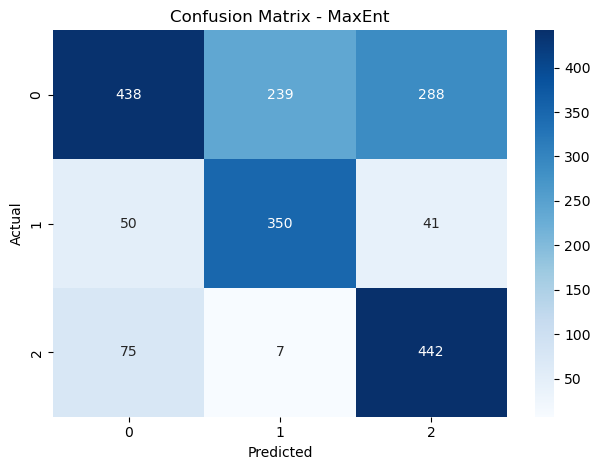

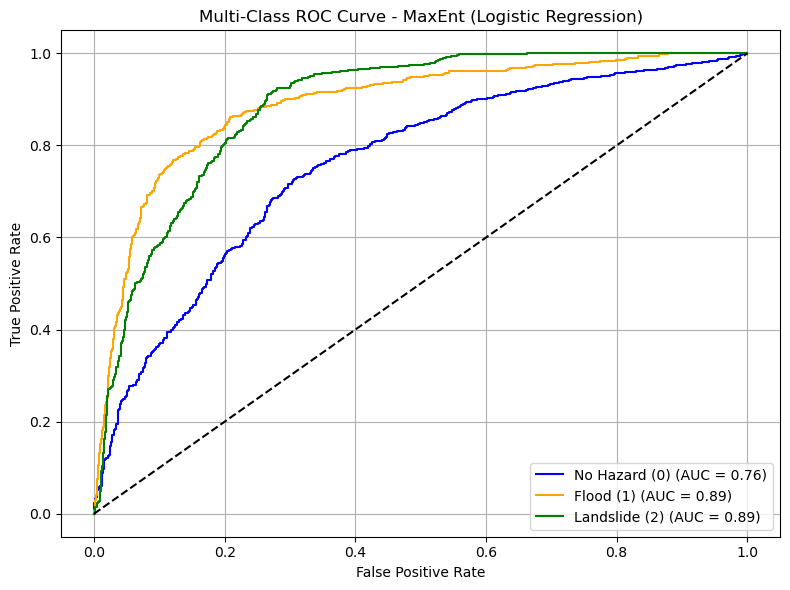

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import ClusterCentroids
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Prepare Data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.fillna(0)

target_column = "Target_Var"
X = df.drop(columns=[target_column, "wkt_geom"], errors="ignore")
y = df[target_column]
classes = sorted(y.unique())

# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# Step 3: Apply ClusterCentroids (Undersampling Majority Class)
cc = ClusterCentroids(random_state=42)
X_train_res, y_train_res = cc.fit_resample(X_train, y_train)

# Step 4: Apply Borderline SMOTE (Oversampling Minority Class)
smote = BorderlineSMOTE(random_state=42, kind='borderline-1')  # 'borderline-1' for minority class focus
X_train_res, y_train_res = smote.fit_resample(X_train_res, y_train_res)

# Step 5: Standardize Features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_res), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# Step 6: Hyperparameter Tuning
param_grid = {'C': [0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(
                        multi_class='multinomial',
                        solver='lbfgs',
                        max_iter=500),
                    param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train_res)
print("Best hyperparameters (GridSearchCV):", grid.best_params_)

# Step 7: Train Best Model
best_model = LogisticRegression(
    solver='lbfgs',
    multi_class='multinomial',
    C=grid.best_params_['C'],
    max_iter=500
)
best_model.fit(X_train_scaled, y_train_res)

# Step 8: Predict
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)

# Step 9: Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = classification_report(y_test, y_pred, output_dict=True)["weighted avg"]["f1-score"]
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 Score (weighted): {f1:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MaxEnt")
plt.tight_layout()
plt.show()

# Step 10: Multi-class ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']
labels = ['No Hazard (0)', 'Flood (1)', 'Landslide (2)']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve - MaxEnt (Logistic Regression)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
import pandas as pd

# Use the correct variable name
df_maxent = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred,
    'Prob_Class_0': y_proba[:, 0],
    'Prob_Class_1': y_proba[:, 1],
    'Prob_Class_2': y_proba[:, 2]
})

save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\MaxEnt_Combined_Results.csv"
df_maxent.to_csv(save_path, index=False)

print(f"Saved MaxEnt multi-class predictions to {save_path}")


Saved MaxEnt multi-class predictions to C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\MaxEnt_Combined_Results.csv


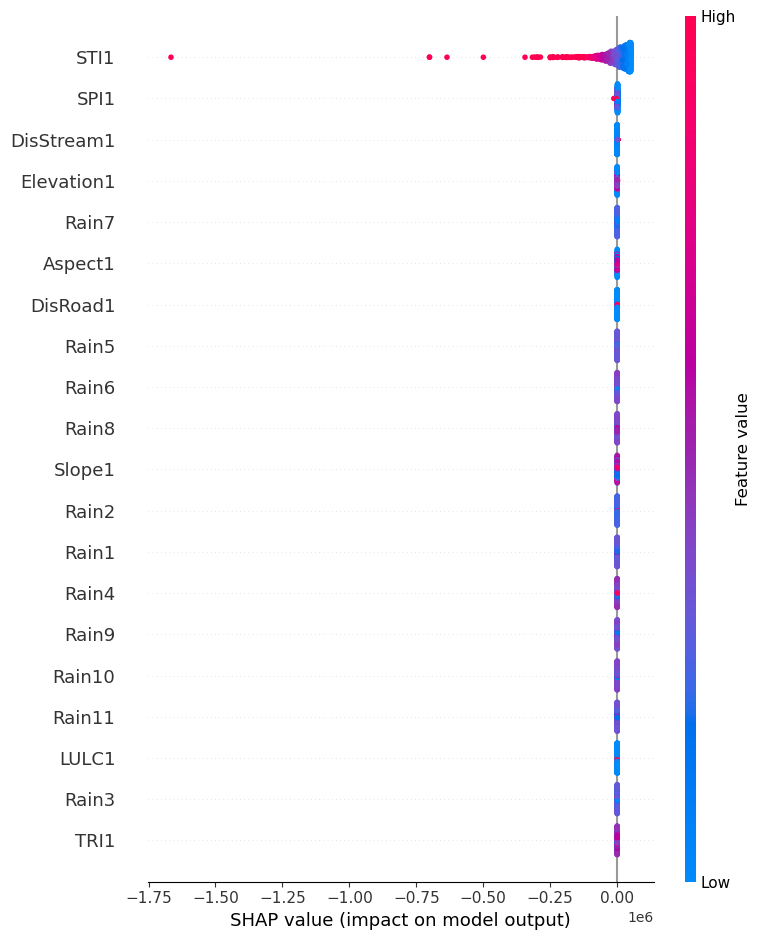

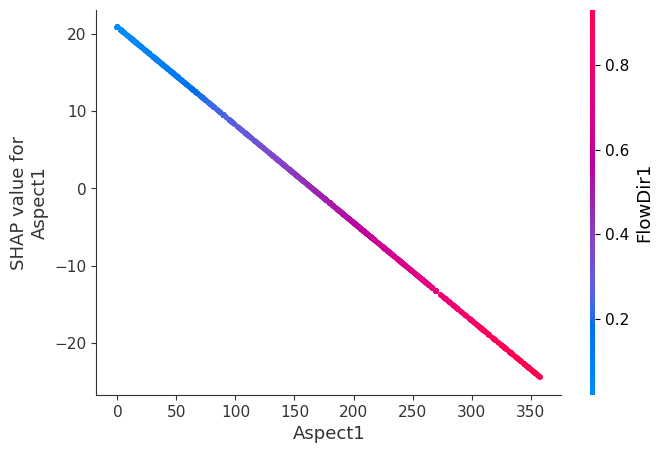

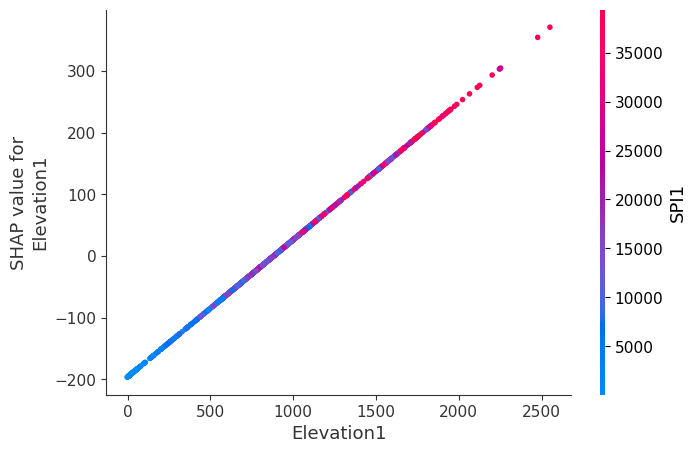

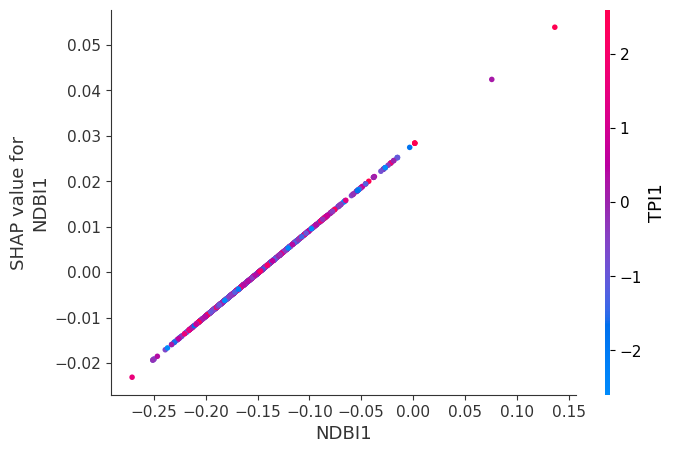

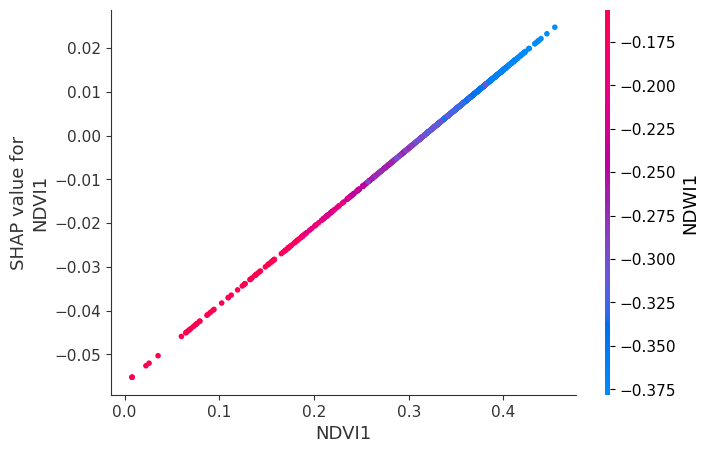

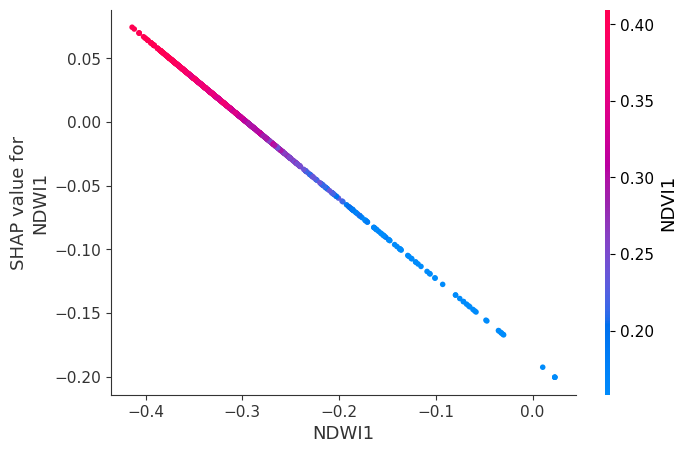


Feature Ranking based on SHAP Values:
       Feature  SHAP Importance
9         STI1     44187.357591
8         SPI1       813.637109
25  DisStream1        93.114936
1   Elevation1        82.303730
19       Rain7        11.546705
0      Aspect1        10.941387
24    DisRoad1         5.932357
17       Rain5         4.502110
18       Rain6         3.545909
20       Rain8         2.787689


In [31]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Retrieve feature names from the original X dataframe
feature_names = X.columns  # Get feature names before standardization

# **Step 7: SHAP Analysis for MaxEnt Model**
explainer = shap.LinearExplainer(best_model, X_train)  # Correct Explainer for Logistic Regression
shap_values = explainer.shap_values(X_test)  # Compute SHAP values

# **Step 8: SHAP Summary Plot (Global Feature Importance)**
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test, feature_names=feature_names)  # Fix: Use original feature names

# **Step 9: SHAP Dependence Plots for Top Features**
for feature_idx in range(min(5, len(feature_names))):  # Limit to 5 features for efficiency
    shap.dependence_plot(feature_names[feature_idx], shap_values, X_test, feature_names=feature_names)

# **Step 10: Feature Ranking using SHAP Values**
shap_mean_contributions = np.abs(shap_values).mean(axis=0)  # Mean absolute SHAP values per feature
feature_ranking = pd.DataFrame({'Feature': feature_names, 'SHAP Importance': shap_mean_contributions})
feature_ranking = feature_ranking.sort_values(by="SHAP Importance", ascending=False)

print("\nFeature Ranking based on SHAP Values:")
print(feature_ranking.head(10))  # Show top 10 important features
